# Agilent E4980A Control Notebook (No Temperature Control)

Interactive notebook for impedance spectroscopy measurements with bias control using only the Agilent E4980A.

**Features:**
- Clean utility functions for stacked measurements
- Flexible Sweep: Vrms and Vdc (loops over lists, single value if list has 1 item)
- Full LCR configuration exposed

**Setup required:**
1. Run `pip install -e .` in `instrument-interfaces/` directory (one time only)
2. Check GPIB addresses match your hardware (see cell 2)
3. Run cells sequentially (Shift+Enter)

## Import

In [2]:
# Imports
from nfoinstruments.drivers import Janis, E4890A
from nfoinstruments.drivers.setup import MeasurementSetup
from nfoinstruments.procedures import (
    set_temperature_and_wait, 
    sweep_frequency_lcr,
    single_frequency_time_scan,
    set_bias_and_wait,
    build_cv_bias_path,
    sweep_cv_lcr,
    load_measurement_files,
    load_cv_measurement_files,
    plot_all_measurements,
    plot_measurement_comparison,
    plot_time_scan_comparison,
    plot_cv_comparison
    )
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Counter for run numbering
run_count = 1

# Output
output_path = Path(r"C:\Users\F110216\Desktop\Data_Horatio\EM024\anneal1")

## Intialise Instruments

In [54]:
# Initialise instruments
mm = MeasurementSetup()

# Connect to devices (update GPIB addresses if needed)
mm.connect_to_devices({
    #'GPIB0::16::INSTR': Janis, # Commented out for Agilent-only run
    'GPIB1::17::INSTR': E4890A
})

# janis = mm.devices['GPIB0::16::INSTR']
lcr = mm.devices['GPIB1::17::INSTR']


['ASRL4::INSTR']
Could not connect to device <class 'nfoinstruments.drivers.lcr.E4890A'> at address GPIB1::17::INSTR
VI_ERROR_CONN_LOST (-1073807194): The connection for the given session has been lost.


KeyError: 'GPIB1::17::INSTR'

## Configure LCR Meter

In [33]:
# Configure LCR meter
# --- Basic Settings ---
lcr.measurement_type = E4890A.MeasurementType.ZTD  # Options: ZTD (Z, θ), RX (R, X), CPD (Cp, D), CSD (Cs, D)...
lcr.measurement_time = E4890A.MeasurementTime.LONG # Options: SHORT, MEDIUM, LONG
lcr.averages = 1                                 # 1 to 256

lcr.signal_type = E4890A.SignalType.VOLTAGE        # VOLTAGE or CURRENT
lcr.signal_amplitude = 0.05                        # Signal Amplitude (V or A)

lcr.bias = 0.0                                     # DC Bias (V)

# --- Advanced Settings ---
lcr.alc_enabled = True                             # Automatic Level Control (True/False)

# --- Corrections (Cable Compensation) ---
# Note: These are typically set to OFF/0 on initialization. 
# Usage: Connect Open/Short/Load standard and enable if needed.
# lcr.resource.write("CORR:OPEN:STAT ON") 
# lcr.resource.write(f"CORR:LENG 1") # Cable length in meters (0, 1, 2, 4)

print(f"LCR configured:")
print(f"  Type: {lcr.measurement_type.name}")
print(f"  Signal: {lcr.signal_amplitude} ({lcr.signal_type.name})")
print(f"  Time: {lcr.measurement_time.name} (Avg: {lcr.averages})")
print(f"  ALC: {lcr.alc_enabled}")

LCR configured:
  Type: ZTD
  Signal: 0.05 (VOLTAGE)
  Time: LONG (Avg: 1)
  ALC: True


## 1: Flexible Measurement Sweep (Vdc + Vrms)
Define your sweep points in the lists below.
- If you only want one value, put it in a list like `[0.0]`. 
- The loops will handle single items automatically.


In [45]:
### Step 1: Define Sweep Parameters
# Define lists for parameters. Use a single item list for fixed values.
#Vdc_points = [-0.5, -0.25, 0.0, 0.25, 0.5]  # List of DC Bias voltages (V)
Vdc_points = [0]                        # Example: Fixed bias

Vrms_points = [0.1]              # List of AC Signal amplitudes (V)
# Vrms_points = [0.05]                      # Example: Fixed amplitude

# Frequency Sweep Configuration
frequency_points = np.round(
    np.logspace(np.log10(20), np.log10(1e6), num=200), 
    decimals=2
)

lcr.measurement_type = E4890A.MeasurementType.ZTD  # Options: ZTD (Z, θ), RX (R, X), CPD (Cp, D), CSD (Cs, D)...

# Output directory setup
sweep_name = "IS_40umcirc_etched_d1"           # Name for this batch of measurements
data_dir = output_path / sweep_name
data_dir.mkdir(parents=True, exist_ok=True) # parents=True creates intermediate dirs if missing

print(f"Settings:")
print(f"- Vdc points ({len(Vdc_points)}): {Vdc_points}")
print(f"- Vrms points ({len(Vrms_points)}): {Vrms_points}")
print(f"- Frequencies: {len(frequency_points)} points")
print(f"- Output Dir: {data_dir}")

### Step 2: Execute Measurement Loop
run_count = 1   # Reset or set starting run number

print(f"\n{'='*60}")
print(f"STARTING MEASUREMENT SEQUENCE")
print(f"{'='*60}")

# Loop over Vrms values (outer loop)
for Vrms in Vrms_points:
    print(f"\nV_{{RMS}} = {Vrms} V")
    lcr.signal_amplitude = Vrms
    time.sleep(0.5) # Time for settings to apply
    
    # Loop over DC bias voltages (inner loop)
    for Vdc in Vdc_points:
        
        # Smart Check: Only set bias if it has changed.
        # This handles both sweeping and fixed cases efficiently.
        if abs(lcr.bias - Vdc) > 0.001:  # Use tolerance for float comparison
            print(f"  Setting V_{{DC}} = {Vdc} V")
            set_bias_and_wait(lcr, Vdc, settle_time=1.0)
        else:
            print(f"  V_{{DC}} = {Vdc} V (Used existing setting)")
        
        # Filename generation - includes both Vdc and Vrms for clarity
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = data_dir / f"run{run_count:03d}_Vrms_{Vrms:.2f}V_Vdc_{Vdc:+.2f}V.csv"
        
        print(f"  measuring -> {filename.name} ... ", end="")
        
        # Timing
        start = time.time() 
        
        try:
            with open(filename, "w") as f:
                # Write header
                f.write(f"# Date: {timestamp}\n")
                f.write(f"# Vrms: {Vrms:.4f} V\n")
                f.write(f"# Vdc: {Vdc:.4f} V\n")
                f.write("# time,bias,frequency,NA,Z,theta\n")
                
                # Run sweep passing None for temp_controller 
                sweep_frequency_lcr(None, lcr, frequency_points, f, verbose=False)
                
            print(f"Write success")
        except Exception as e:
            print(f" Error: {e}")
            import traceback
            traceback.print_exc()
        
        run_count += 1
        
        # Timing
        end = time.time()
        elapsed = end - start
        # convert seconds → h:m:s
        hours, rem = divmod(elapsed, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"  Elapsed time: {int(hours):02d}:{int(minutes):02d}:{seconds:05.2f}")

print(f"\n{'='*60}")
print(f"SEQUENCE COMPLETE")
print(f"{'='*60}")

print(f'final run number = {run_count}')




Settings:
- Vdc points (1): [0]
- Vrms points (1): [0.1]
- Frequencies: 200 points
- Output Dir: C:\Users\F110216\Desktop\Data_Horatio\EM024\IS_40umcirc_etched_d1

STARTING MEASUREMENT SEQUENCE

V_{RMS} = 0.1 V
  V_{DC} = 0 V (Used existing setting)
  measuring -> run001_Vrms_0.10V_Vdc_+0.00V.csv ... Write success
  Elapsed time: 00:01:45.44

SEQUENCE COMPLETE
final run number = 2


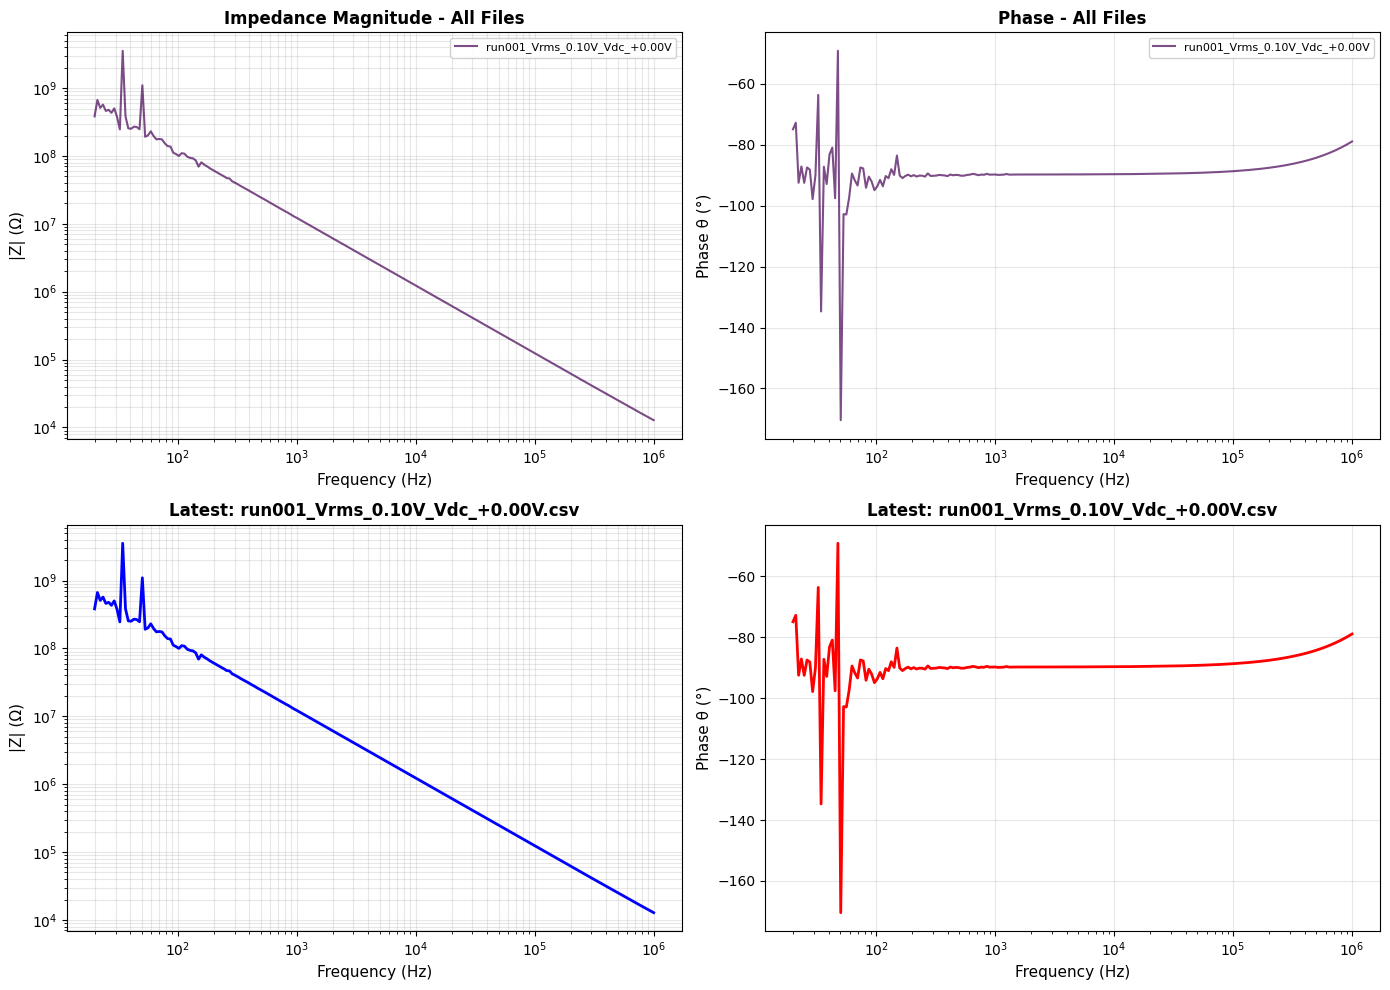


Plotted 1 files from C:\Users\F110216\Desktop\Data_Horatio\EM024\IS_40umcirc_etched_d1


In [46]:
### Step 3: Plot Measurements for quick overview
# Load all data files
fig, axes, datasets = plot_all_measurements(data_dir, pattern="run*.csv", figsize=(14, 10), show_legend=True)

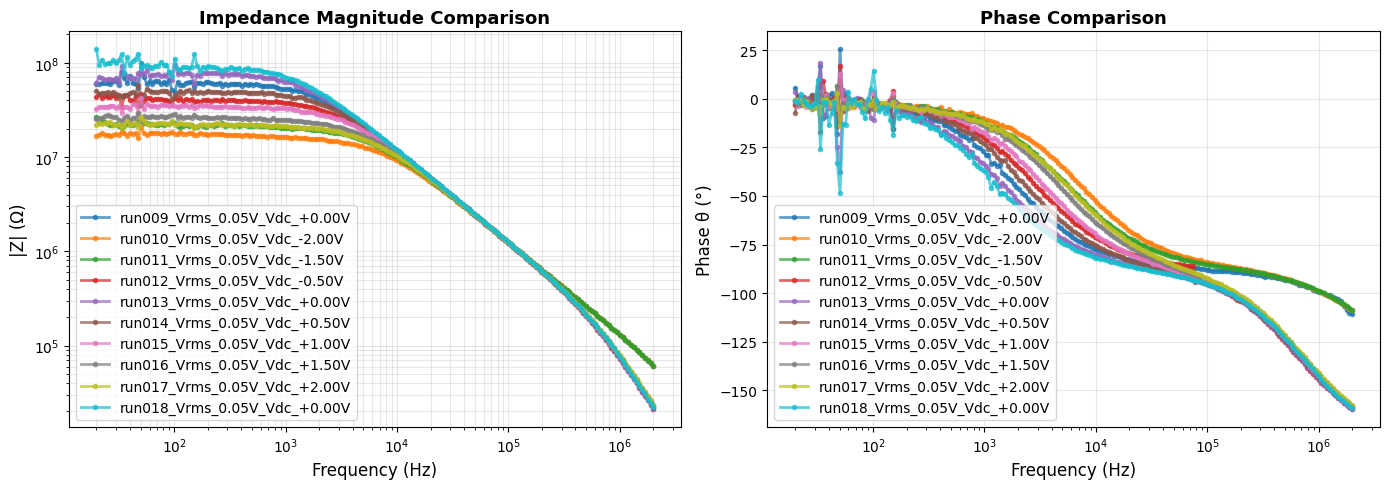

In [167]:
# Plot specific files for detailed comparison
# Example: Compare first 3 files
# Uncomment and modify the list to select specific files

plot_measurement_comparison(data_dir, file_indices=[8,9,10, 11, 12, 13 ,14,15, 16,17,18,19], figsize=(14, 5), show_legend=True)

## 2. CV Sweep
- Sweeping the DC voltage and measuring the capacitance at several frequencies for transistor depletion

In [ ]:
### Step 1: Define CV Sweep Parameters
# CV loop shape: 0 -> +Vmax -> Vmin -> 0
Vmin = -9
Vmax = 9
Vstep = 0.1

# Set run numbering for CV sequence
run_count = 1

# AC condition list (outer loop). Use [0.05] for fixed Vrms.
Vrms_points = [0.1]

# Frequency list for CV scans
freq_points = [1e4]

# Set up cycling to repeat the measurement with the same conditions 
cycles = 5  # Number of times to repeat the entire CV sequence (with same conditions) - by default 1 (no repeat)

# Build ordered DC trajectory once
Vdc_path = build_cv_bias_path(v_min=Vmin, v_max=Vmax, v_step=Vstep)

# Configure LCR for CV mode (Cp, Gp)
lcr.measurement_type = E4890A.MeasurementType.CPG

# Output directory setup
sweep_name = "CV_40umetchedcirc_dev1"
data_dir = output_path / sweep_name
data_dir.mkdir(parents=True, exist_ok=True)

print("CV settings:")
print(f"- Vdc path points: {len(Vdc_path)}")
print(f"- Vdc start/end: {Vdc_path[0]:.2f} V -> {Vdc_path[-1]:.2f} V")
print(f"- Vdc min/max: {min(Vdc_path):.2f} V / {max(Vdc_path):.2f} V")
print(f"- Vrms points: {Vrms_points}")
print(f"- Frequencies: {freq_points}")
print(f"- Output Dir: {data_dir}")

### Step 2: Execute CV Measurement Loops


print(f"\n{'='*60}")
print("STARTING CV SEQUENCE")
print(f"{'='*60}")

# Cycle through the entire CV sequence multiple times if desired (repeat loop)
for r in range(1,cycles+1,1):
    
    for Vrms in Vrms_points:
        lcr.signal_amplitude = Vrms
        time.sleep(0.5)
        print(f"\nVrms = {Vrms:.3f} V")

        for freq in freq_points:
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            filename = data_dir / (
                f"run{run_count:03d}_CV_{int(freq)}Hz_Vrms_{Vrms:.3f}V_"
                f"Vmin_{Vmin:+.2f}V_Vmax_{Vmax:+.2f}V_step_{Vstep:.3f}V.csv"
            )

            print(f"  CV sweep @ {freq:.0f} Hz -> {filename.name}")
            start = time.time()

            try:
                with open(filename, "w") as f:
                    f.write(f"# Date: {timestamp}\n")
                    f.write("# Type: CV_Scan\n")
                    f.write(f"# Frequency: {freq} Hz\n")
                    f.write(f"# Vrms: {Vrms:.6f} V\n")
                    f.write(f"# Vmin: {Vmin:.6f} V\n")
                    f.write(f"# Vmax: {Vmax:.6f} V\n")
                    f.write(f"# Vstep: {Vstep:.6f} V\n")
                    f.write("# time,bias,frequency,NA,Cp,Gp\n")

                    sweep_cv_lcr(
                        temp_controller=None,
                        lcr=lcr,
                        frequency=freq,
                        bias_points=Vdc_path,
                        output_file=f,
                        verbose=True,
                        settle_time=0.1,
                    )

                print("    Write success")
            except Exception as e:
                print(f"    Error: {e}")
                import traceback
                traceback.print_exc()

            elapsed = time.time() - start
            hours, rem = divmod(elapsed, 3600)
            minutes, seconds = divmod(rem, 60)
            print(f"    Elapsed time: {int(hours):02d}:{int(minutes):02d}:{seconds:05.2f}")

            run_count += 1

print(f"\n{'='*60}")
print("CV SEQUENCE COMPLETE")
print(f"{'='*60}")
print(f"Final run number = {run_count}")

CV settings:
- Vdc path points: 361
- Vdc start/end: 0.00 V -> -0.00 V
- Vdc min/max: -9.00 V / 9.00 V
- Vrms points: [0.1]
- Frequencies: [10000.0]
- Output Dir: C:\Users\F110216\Desktop\Data_Horatio\EM024\CV_40umetchedcirc_dev1

STARTING CV SEQUENCE

Vrms = 0.100 V
  CV sweep @ 10000 Hz -> run001_CV_10000Hz_Vrms_0.100V_Vmin_-9.00V_Vmax_+9.00V_step_0.100V.csv
  Progress: 361/361 bias points
    CV sweep complete (361 points @ 1e+04 Hz)
    Write success
    Elapsed time: 00:02:06.99

CV SEQUENCE COMPLETE
Final run number = 2


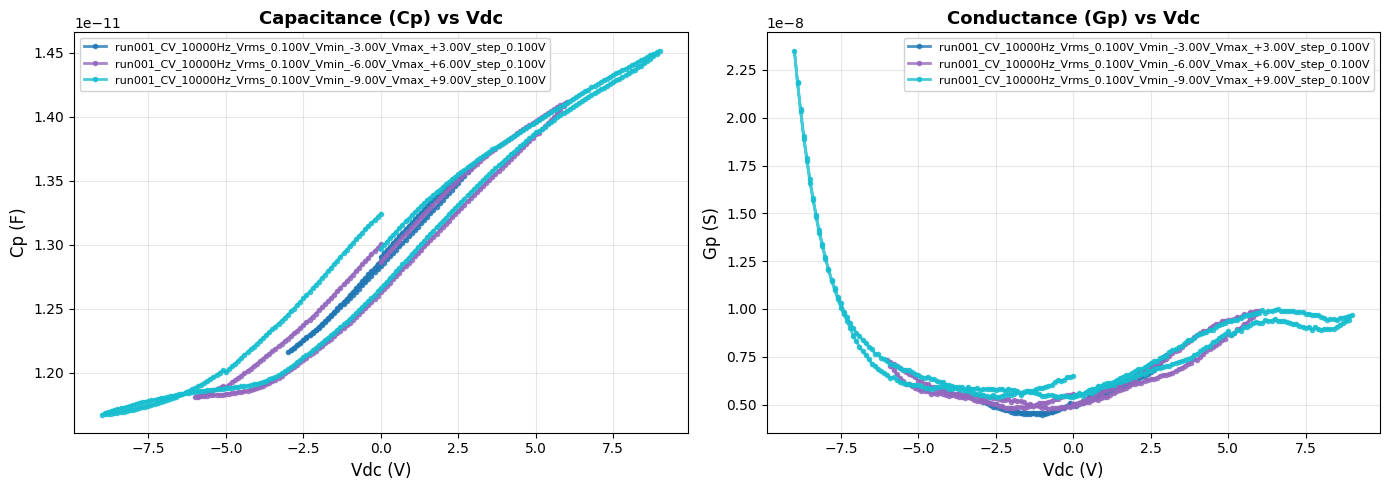

In [52]:
### Step 3: Plot CV results (all files or selected indices)
#sweep_name = "40umetchedcirc_dev1"
data_dir = output_path / sweep_name

# Plot all CV files in directory
plot_cv_comparison(data_dir, pattern="run*.csv", file_indices=None, figsize=(14, 5), show_legend=True)

# Plot selected files only (example):
# plot_cv_comparison(data_dir, pattern="run*.csv", file_indices=[0, 1], figsize=(14, 5), show_legend=True)

## 3: Agilent Only - Single Frequency vs Time
- Measuring the drift of Z with time when held at a single frequency and $V_{RMS}$ and/or $V_{DC}$

In [ ]:
### Step 1: Define Time Scan Parameters
# Parameters for DRIFT measurement
Vdc_points = [0]        # List of DC Bias voltages (V)
Vrms_points = [0.05, ]             # List of AC Signal amplitudes (V)
target_frequency_points = [37e3]       # Single frequency to hold (Hz)
scan_duration = 300          # Duration per measurement (seconds) (e.g., 5 mins = 300s)

# Output directory setup
sweep_name = "timescan_parallel_w05um_g1um_dev2_nextday"
data_dir = output_path / sweep_name
data_dir.mkdir(parents=True, exist_ok=True)

print(f"Settings:")
print(f"- Frequency: {target_frequency_points} Hz")
print(f"- Duration: {scan_duration} seconds per run")
print(f"- Vdc points: {Vdc_points}")
print(f"- Vrms points: {Vrms_points}")

### Step 2: Execute Measurement Loop
run_count = 23

print(f"\n{'='*60}")
print(f"STARTING TIME DRIFT SEQUENCE")
print(f"{'='*60}")

for target_frequency in target_frequency_points:
    # Loop over Vrms values (outer loop)
    for Vrms in Vrms_points:
        print(f"\nV_{{RMS}} = {Vrms} V")
        lcr.signal_amplitude = Vrms
        time.sleep(0.5) 
        
        # Loop over DC bias voltages (inner loop)
        for Vdc in Vdc_points:
            
            # Smart Check: Only set bias if it has changed.
            if abs(lcr.bias - Vdc) > 0.001:
                print(f"  Setting V_{{DC}} = {Vdc} V")
                set_bias_and_wait(lcr, Vdc, settle_time=1.0)
            else:
                print(f"  V_{{DC}} = {Vdc} V (Used existing setting)")
            
            # Filename generation
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            filename = data_dir / f"run{run_count:03d}_DRIFT_{int(target_frequency)}Hz_Vrms_{Vrms:.2f}V_Vdc_{Vdc:+.2f}V.csv"
            
            print(f"  Measuring drift ({scan_duration}s) -> {filename.name}")
            
            try:
                with open(filename, "w") as f:
                    # Write header
                    f.write(f"# Date: {timestamp}\n")
                    f.write(f"# Type: Time_Scan\n")
                    f.write(f"# Duration: {scan_duration} s\n")
                    f.write(f"# Frequency: {target_frequency} Hz\n")
                    f.write(f"# Vrms: {Vrms:.4f} V\n")
                    f.write(f"# Vdc: {Vdc:.4f} V\n")
                    f.write("# time,bias,frequency,NA,Z,theta\n")
                    
                    # Run single frequency time scan (Agilent only)
                    single_frequency_time_scan(None, lcr, target_frequency, scan_duration, f, verbose=True)
                    
                print(f"    Write success")
            except Exception as e:
                print(f"    Error: {e}")
                import traceback
                traceback.print_exc()
            
            run_count += 1

print(f"\n{'='*60}")
print(f"SEQUENCE COMPLETE")
print(f"{'='*60}")



Settings:
- Frequency: [37000.0] Hz
- Duration: 300 seconds per run
- Vdc points: [0]
- Vrms points: [0.05, 9.5, 0.05, 9.5, 0.05]

STARTING TIME DRIFT SEQUENCE

V_{RMS} = 0.05 V
  V_{DC} = 0 V (Used existing setting)
  Measuring drift (300s) -> run023_DRIFT_37000Hz_Vrms_0.05V_Vdc_+0.00V.csv
  Time: 298.3/300.0s | Points: 2367 | Z: 1.54e+05 Ohm
    Time scan complete: 2381 points in 300.0s
    Write success

V_{RMS} = 9.5 V
  V_{DC} = 0 V (Used existing setting)
  Measuring drift (300s) -> run024_DRIFT_37000Hz_Vrms_9.50V_Vdc_+0.00V.csv
  Time: 298.2/300.0s | Points: 2377 | Z: 1.27e+05 Ohm
    Time scan complete: 2392 points in 300.0s
    Write success

V_{RMS} = 0.05 V
  V_{DC} = 0 V (Used existing setting)
  Measuring drift (300s) -> run025_DRIFT_37000Hz_Vrms_0.05V_Vdc_+0.00V.csv
  Time: 299.0/300.0s | Points: 2370 | Z: 1.54e+05 Ohm
    Time scan complete: 2378 points in 300.0s
    Write success

V_{RMS} = 9.5 V
  V_{DC} = 0 V (Used existing setting)
  Measuring drift (300s) -> run026_

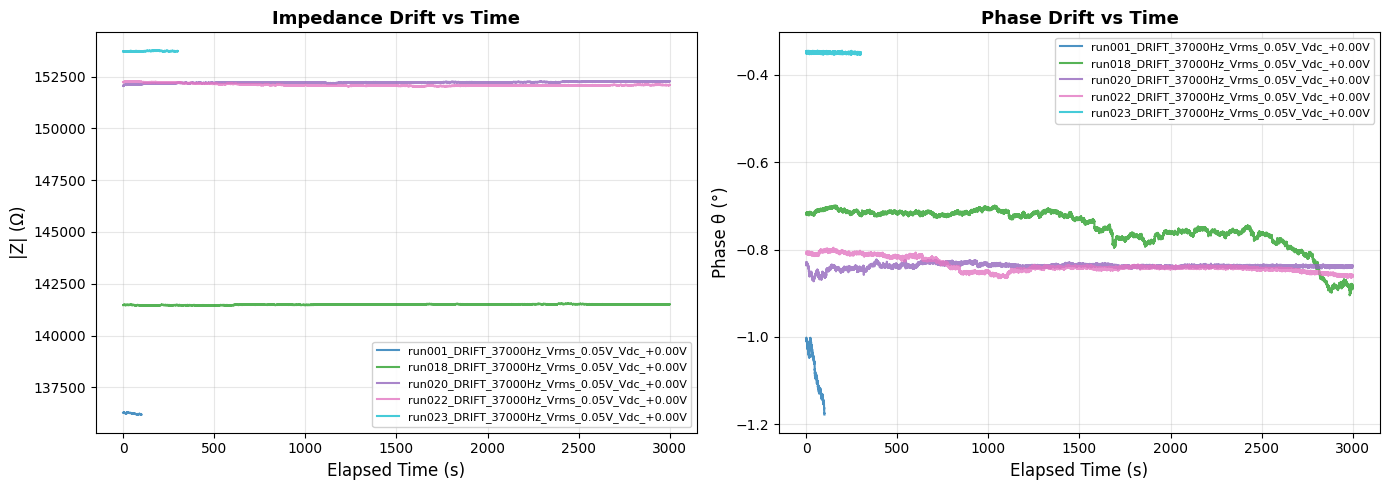

In [146]:
sweep_name ="timescan_parallel_w05um_g1um_dev2_nextday"
data_dir = output_path / sweep_name

### Step 3: Plot Measurements [0,2,5,7,9,10,12, 13, 15]
# Re-load data from the specific drift directory
plot_time_scan_comparison(data_dir, file_indices=[0,1, 3, 5, 7], show_legend=True, normalise = False)

## Plotting

In [ ]:
# Load all measurement files from data directory
import os

# Make sure data directory exists
#os.makedirs("data", exist_ok=True)

# Load all data files
datasets = load_measurement_files(output_path, pattern="run*.csv")

if datasets:
    print(f"Loaded {len(datasets)} files:\n")
    for filename, df in datasets:
        bias_mean = df['bias'].mean()
        freq_range = f"{df['frequency'].min():.0f} - {df['frequency'].max():.0f}"
        print(f"  {filename}: {len(df)} points, Bias={bias_mean:.3f}V, Freq={freq_range} Hz")
    
    # Show latest file in detail
    latest_file, latest_df = datasets[-1]
    print(f"\n=== Latest File: {latest_file} ===")
    print(latest_df.head())
else:
    print("No data files found yet - run a measurement first!")

In [ ]:
# Plot all measurements together
# This creates a 2x2 plot:
# - Top: All files overlaid (impedance & phase)
# - Bottom: Latest file in detail

# Set show_legend=False to hide the legend if you have many files
fig, axes, datasets = plot_all_measurements(output_path, pattern="run*.csv", file_indices = None, figsize=(14, 10), show_legend=True)

## Quick Reference & Status Check

**Utility Functions Used:**
- `set_temperature_and_wait(controller, temp, extra_settle_time, verbose)` - Set temp and wait for stability
- `set_bias_and_wait(lcr, bias, settle_time)` - Set DC bias and wait
- `sweep_frequency_lcr(controller, lcr, frequencies, file, verbose)` - Perform frequency sweep

**Common Measurement Types:**
- `E4890A.MeasurementType.ZTD` - Impedance magnitude |Z| and phase θ
- `E4890A.MeasurementType.RX` - Resistance R and reactance X
- `E4890A.MeasurementType.CPD` - Parallel capacitance Cp and dissipation D

**Measurement Times:**
- `SHORT` - Fast, less accurate
- `MEDIUM` - Balanced (recommended)
- `LONG` - Slow, most accurate

## Diagnostics & Troubleshooting

In [ ]:
# Diagnose Janis controller status
# Run this if temperature isn't stabilizing

status = janis.get_controller_status()
print("=== Janis Controller Diagnostics ===")
for key, value in status.items():
    print(f"{key}: {value}")

print("\n=== Action: Force temperature control mode ===")
janis.temperature_setpoint = 10.0  # This now also sends MODE 2 command
print(f"Setpoint updated to {janis.temperature_setpoint} K")
print(f"Temperature control mode activated")
print(f"\nCurrent temp: {janis.temperature:.2f} K")
print(f"Waiting for heater to activate...")

### Simulating Impedance Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_impedance(R1, C1, R2, C2, label_text):
    """
    Calculates and plots the impedance magnitude and phase for a series combination
    of two parallel RC circuits.

    Args:
        R1 (float): Resistance of the first RC element in Ohms.
        C1 (float): Capacitance of the first RC element in Farads.
        R2 (float): Resistance of the second RC element in Ohms.
        C2 (float): Capacitance of the second RC element in Farads.
        label_text (str): Label for the plot legend.
    """
    # Define the frequency range (from 1 mHz to 1 MHz)
    frequencies = np.logspace(-3, 6, 500)
    omega = 2 * np.pi * frequencies

    # Calculate the impedance of each parallel RC element
    # Z_RC = 1 / (1/R + jwC)
    Z1 = 1 / (1/R1 + 1j * omega * C1)
    Z2 = 1 / (1/R2 + 1j * omega * C2)

    # Total impedance is the sum of the two elements in series
    Z_total = Z1 + Z2

    # Calculate impedance magnitude and phase
    Z_magnitude = np.abs(Z_total)
    Z_phase = np.angle(Z_total, deg=True)

    # Plotting
    ax[0].loglog(frequencies, Z_magnitude, label=label_text)
    ax[1].semilogx(frequencies, Z_phase, label=label_text)

# --- Main Plotting Setup ---
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# --- Plot Example 1: Well-separated time constants ---
# High-frequency RC element (smaller time constant) shorts first,
# then the low-frequency element (larger time constant) shorts.
R1, C1 = 1e5, 1e-9  # Low-freq: tau1 = R1*C1 = 100 us
R2, C2 = 1e3, 1e-12 # High-freq: tau2 = R2*C2 = 1 ns
plot_impedance(R1, C1, R2, C2, 'Ex 1: R1=100kΩ, C1=1nF | R2=1kΩ, C2=1pF')


# --- Plot Example 2: Closer time constants ---
# The plateau between the two drops is less distinct.
R1, C1 = 1e4, 1e-8  # tau1 = 100 us
R2, C2 = 1e3, 1e-9  # tau2 = 1 us
plot_impedance(R1, C1, R2, C2, 'Ex 2: R1=10kΩ, C1=10nF | R2=1kΩ, C2=1nF')


# --- Plot Example 3: Different resistance dominance ---
# The lower resistance element defines the plateau.
R1, C1 = 1e3, 1e-7  # Low-freq: tau1 = 100 us
R2, C2 = 1e5, 1e-12 # High-freq: tau2 = 100 ns
plot_impedance(R1, C1, R2, C2, 'Ex 3: R1=1kΩ, C1=100nF | R2=100kΩ, C2=1pF')


# --- Formatting the Plots ---
# Magnitude Plot
ax[0].set_ylabel('Impedance Magnitude |Z| (Ω)')
ax[0].set_title('Impedance Bode Plot for (R1||C1) + (R2||C2) Circuit')
ax[0].grid(True, which="both", ls="--")
ax[0].legend()

# Phase Plot
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Phase Angle (degrees)')
ax[1].grid(True, which="both", ls="--")
ax[1].legend()

plt.tight_layout()
plt.show()